# 165,000 km de ríos donde el océano manda

Imagina un río a 200 km de la costa. El agua dulce baja, sí. Pero dos veces al día, el océano empuja de vuelta. La marea sube río arriba, frena la corriente, y por unas horas el río fluye al revés.

Hasta ahora, nadie había medido esto a escala global. El satélite SWOT (Surface Water and Ocean Topography) lo cambió: en un solo barrido, mapeó la influencia de las mareas en **3,172 ríos costeros** del mundo.

---

📄 **Paper:** Pietsch et al. (2026), *Nature*
🔗 **DOI:** [10.1038/s41586-026-10287-z](https://doi.org/10.1038/s41586-026-10287-z)
📺 **Video:** [Ver en YouTube](https://youtube.com/watch?v=wLwm8P0S1LY)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-22-rios-mareas-swot-satelite/notebook.ipynb)

## ¿Cómo mides las mareas en miles de ríos?

Hasta 2023, medir mareas en ríos requería estaciones de monitoreo físicas. El problema: hay muy pocas, y están concentradas en países ricos. La mayoría de los ríos costeros del mundo nunca se habían medido.

El satélite SWOT, lanzado en diciembre de 2022, usa un altímetro de radar con un barrido de 120 km de ancho (los anteriores medían una línea de ~10 km). Con cada pasada, mide la altura del agua con precisión centimétrica. Combinando cientos de pasadas, el equipo extrajo el **patrón de mareas** — la señal periódica que el océano inyecta río arriba.

Los datos cubren **41,910 tramos de ríos** (segmentos del catálogo SWORD v17) en todos los continentes.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_TIDAL = 0.10      # Amplitud mínima (m) para considerar tidal
FUENTE = 'Fuente: Pietsch et al. (2026), Nature | Datos: Zenodo CC BY 4.0'
COLOR_TIDAL = '#2563EB'
COLOR_NO_TIDAL = '#BBBBBB'
COLOR_ALERTA = '#DC2626'
COLOR_SEMI = '#2563EB'
COLOR_MIXTA = '#059669'
COLOR_DIURNA = '#D97706'

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos (descarga automática en Colab, local en repo)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-22-rios-mareas-swot-satelite'
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

archivos = ['rios_mareas.csv', 'resumen_continentes.csv',
            'distribucion_amplitudes.csv', 'tipo_marea_por_rio.csv']
for archivo in archivos:
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{archivo}', f'datos/{archivo}')

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE.rsplit("/papers", 1)[0]}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
rios = pd.read_csv('datos/rios_mareas.csv')
continentes = pd.read_csv('datos/resumen_continentes.csv')
tipos = pd.read_csv('datos/tipo_marea_por_rio.csv')
hist_data = pd.read_csv('datos/distribucion_amplitudes.csv')

print(f"Tramos de río cargados: {len(rios):,}")
print(f"  Con influencia de mareas: {(rios['es_tidal'] == 'sí').sum():,} ({(rios['es_tidal'] == 'sí').mean()*100:.1f}%)")
print(f"  Con amplitud medida: {rios['amplitud_media_m'].notna().sum():,}")
print(f"  Continentes: {len(continentes)}")
print(f"  Tipos de marea: {len(tipos):,} tramos clasificados")

Tramos de río cargados: 41,910
  Con influencia de mareas: 20,910 (49.9%)
  Con amplitud medida: 8,421
  Continentes: 9
  Tipos de marea: 8,421 tramos clasificados


## La mitad de los ríos del mundo tiene pulso de océano

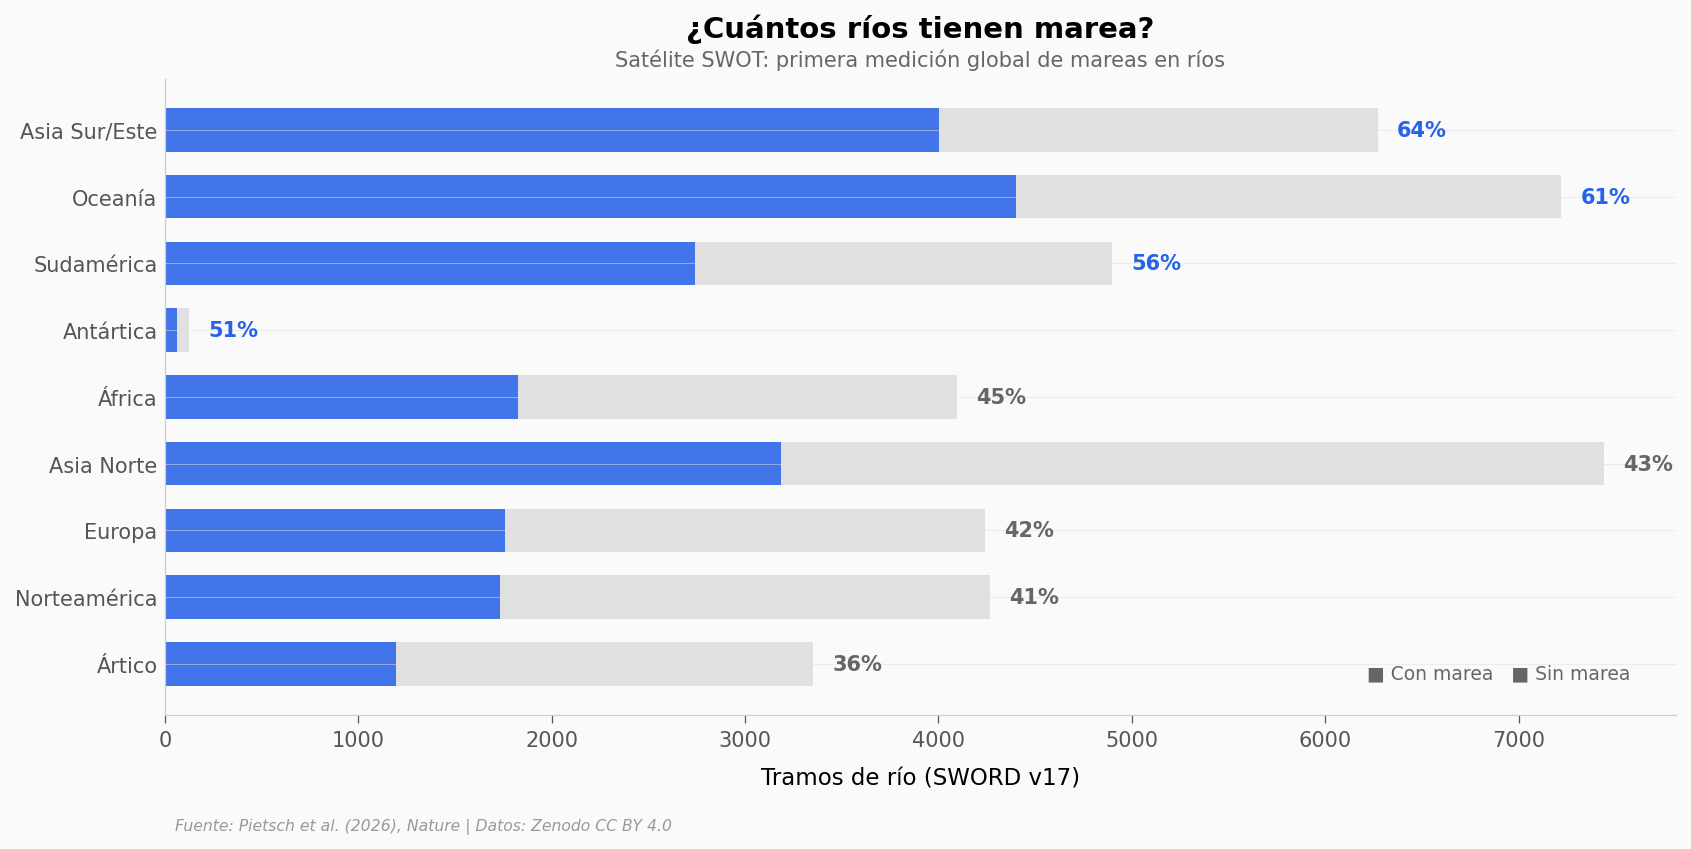

In [2]:
# ── Gráfica 1: ¿Cuántos ríos tienen marea por continente? ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por % tidal
cont_sorted = continentes.sort_values('pct_rios_tidal', ascending=True)

y_pos = np.arange(len(cont_sorted))
bar_height = 0.65

# Barras: tidal vs total
ax.barh(y_pos, cont_sorted['rios_total'], height=bar_height,
        color=COLOR_NO_TIDAL, alpha=0.4, label='Sin marea')
ax.barh(y_pos, cont_sorted['rios_con_marea'], height=bar_height,
        color=COLOR_TIDAL, alpha=0.85, label='Con marea')

# Inline labels con porcentaje
for i, (_, row) in enumerate(cont_sorted.iterrows()):
    pct = row['pct_rios_tidal']
    ax.text(row['rios_total'] + 100, i, f"{pct:.0f}%",
            va='center', fontsize=10, fontweight='bold',
            color=COLOR_TIDAL if pct > 50 else '#666666')

ax.set_yticks(y_pos)
ax.set_yticklabels(cont_sorted['continente'], fontsize=10)
ax.set_xlabel('Tramos de río (SWORD v17)', fontsize=11)
ax.set_title('¿Cuántos ríos tienen marea?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Satélite SWOT: primera medición global de mareas en ríos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda minimalista
ax.text(0.97, 0.05, '■ Con marea   ■ Sin marea',
        transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
        color='#666666')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rios_tidal_por_continente.png', dpi=200, bbox_inches='tight')
plt.show()

Cada barra muestra los tramos de río monitoreados por el SWOT. El azul son los que tienen señal de marea detectable. El porcentaje a la derecha es la fracción tidal.

**Oceanía y Asia Sur/Este** lideran: más del 60% de sus ríos tienen influencia oceánica (Oceanía: 4,401/7,219 tramos, 61%; Asia Sur/Este: 4,005/6,271, 64%). Tiene sentido — costas largas, muchos deltas, y rangos de marea altos en el Pacífico e Índico.

El **Ártico** tiene la menor proporción (36%, 1,196/3,351 tramos). Los ríos siberianos y canadienses son enormes pero desembocan en mares con mareas débiles.

> **Nota:** Estos son "tramos" SWORD (segmentos de ~10 km), no ríos completos. El paper reporta 3,172 sistemas fluviales agrupando múltiples tramos.

## ¿Qué tan fuerte es la señal?

Una cosa es detectar mareas en un río. Otra es que sean relevantes. Veamos la amplitud — cuánto sube y baja el nivel del agua por efecto del océano.

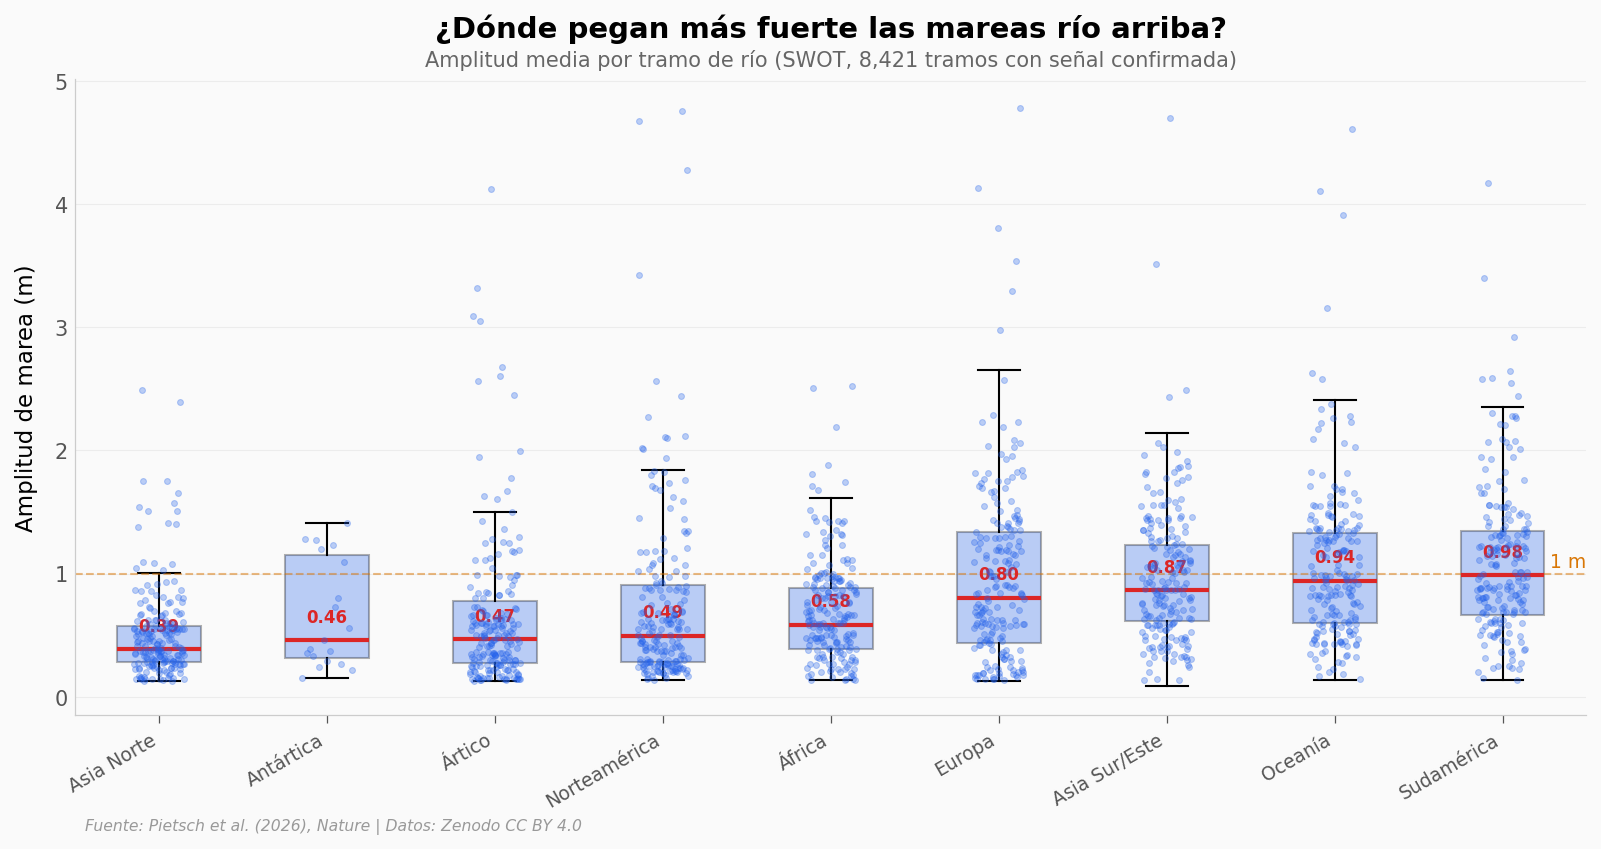

In [3]:
# ── Gráfica 2: Amplitud de mareas por continente ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Solo reaches con amplitud medida
rios_amp = rios[rios['amplitud_media_m'].notna()].copy()

# Ordenar continentes por amplitud mediana
orden = rios_amp.groupby('continente')['amplitud_media_m'].median().sort_values(ascending=True)
continentes_ord = orden.index.tolist()

positions = list(range(len(continentes_ord)))
np.random.seed(42)

for i, cont in enumerate(continentes_ord):
    vals = rios_amp[rios_amp['continente'] == cont]['amplitud_media_m'].values
    # Box plot
    bp = ax.boxplot([vals], positions=[i], widths=0.5, patch_artist=True,
                    showfliers=False, medianprops=dict(color=COLOR_ALERTA, linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_TIDAL)
    bp['boxes'][0].set_alpha(0.3)
    
    # Scatter con jitter
    n = min(len(vals), 200)  # Limitar puntos para legibilidad
    sample = np.random.choice(vals, n, replace=False) if len(vals) > 200 else vals
    x_jitter = np.linspace(i - 0.15, i + 0.15, len(sample))
    np.random.shuffle(x_jitter)
    ax.scatter(x_jitter, sample, color=COLOR_TIDAL, s=8, alpha=0.3, zorder=5)
    
    # Mediana como texto
    med = np.median(vals)
    ax.text(i, med + 0.15, f'{med:.2f}', ha='center', fontsize=8,
            fontweight='bold', color=COLOR_ALERTA)

ax.set_xticks(positions)
ax.set_xticklabels(continentes_ord, fontsize=9, rotation=30, ha='right')
ax.set_ylabel('Amplitud de marea (m)', fontsize=11)
ax.set_title('¿Dónde pegan más fuerte las mareas río arriba?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Amplitud media por tramo de río (SWOT, 8,421 tramos con señal confirmada)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Línea de referencia: 1 metro
ax.axhline(y=1.0, color='#D97706', linewidth=1, linestyle='--', alpha=0.5)
ax.text(len(continentes_ord) - 0.5, 1.05, '1 m', fontsize=9, color='#D97706', ha='right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/amplitud_por_continente.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tipo de marea entra en cada río?

No todas las mareas son iguales. La marea tiene dos componentes principales:
- **M2** (semidiurna): la marea clásica — sube y baja dos veces al día, cada ~12.4 horas. La genera la Luna.
- **O1** (diurna): sube y baja una vez al día, cada ~25.8 horas.

El ratio O1/M2 nos dice qué tipo domina. Si es bajo (<0.25), el río tiene marea semidiurna. Si es alto (>1.5), diurna. En el medio: mixta.

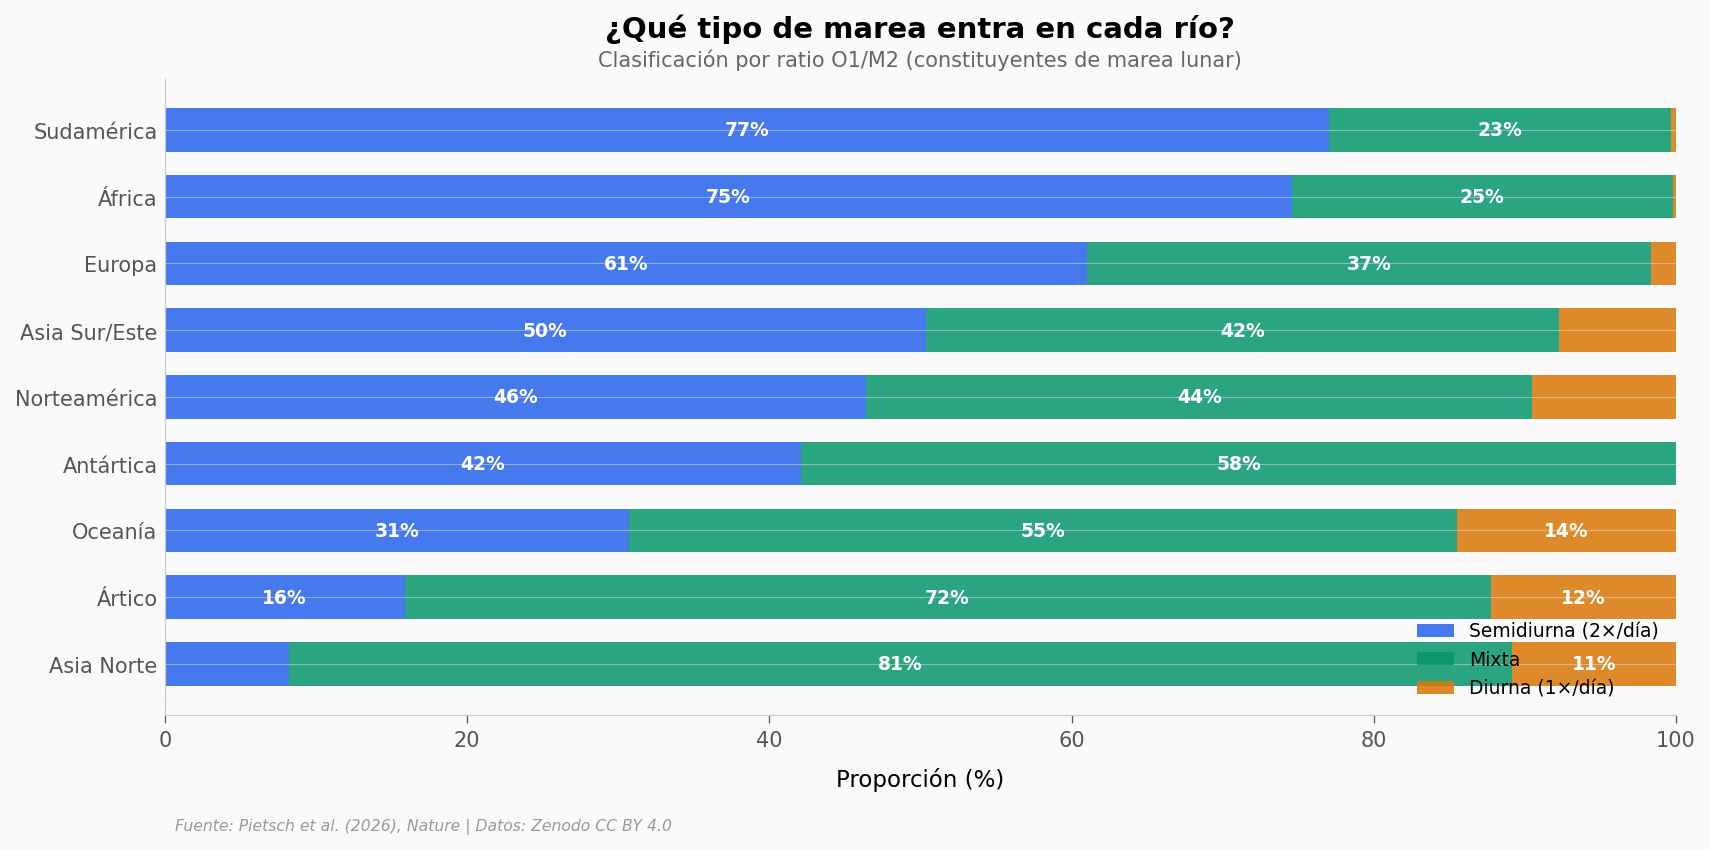

In [4]:
# ── Gráfica 3: Tipo de marea por continente ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Contar tipos por continente
tipo_counts = tipos.groupby(['continente', 'tipo_marea']).size().unstack(fill_value=0)

# Asegurar columnas en orden
for col in ['semidiurna', 'mixta', 'diurna']:
    if col not in tipo_counts.columns:
        tipo_counts[col] = 0
tipo_counts = tipo_counts[['semidiurna', 'mixta', 'diurna']]

# Normalizar a porcentaje
tipo_pct = tipo_counts.div(tipo_counts.sum(axis=1), axis=0) * 100

# Ordenar por % semidiurna
tipo_pct = tipo_pct.sort_values('semidiurna', ascending=True)

y_pos = np.arange(len(tipo_pct))
bar_height = 0.65

# Stacked horizontal bars
left = np.zeros(len(tipo_pct))
colors = [COLOR_SEMI, COLOR_MIXTA, COLOR_DIURNA]
labels = ['Semidiurna (2×/día)', 'Mixta', 'Diurna (1×/día)']

for col, color, label in zip(['semidiurna', 'mixta', 'diurna'], colors, labels):
    widths = tipo_pct[col].values
    ax.barh(y_pos, widths, left=left, height=bar_height, color=color, alpha=0.85, label=label)
    # Inline labels for significant portions
    for i, (w, l) in enumerate(zip(widths, left)):
        if w > 10:
            ax.text(l + w/2, i, f'{w:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    left += widths

ax.set_yticks(y_pos)
ax.set_yticklabels(tipo_pct.index, fontsize=10)
ax.set_xlabel('Proporción (%)', fontsize=11)
ax.set_title('¿Qué tipo de marea entra en cada río?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Clasificación por ratio O1/M2 (constituyentes de marea lunar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim(0, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tipo_marea_por_continente.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan extremas pueden ser las mareas en un río?

La amplitud mediana es 0.78 m — menos de un metro. Pero los extremos llegan casi a 5 metros. Eso es un río que cambia de dirección, de salinidad, y de ecosistema dos veces al día.

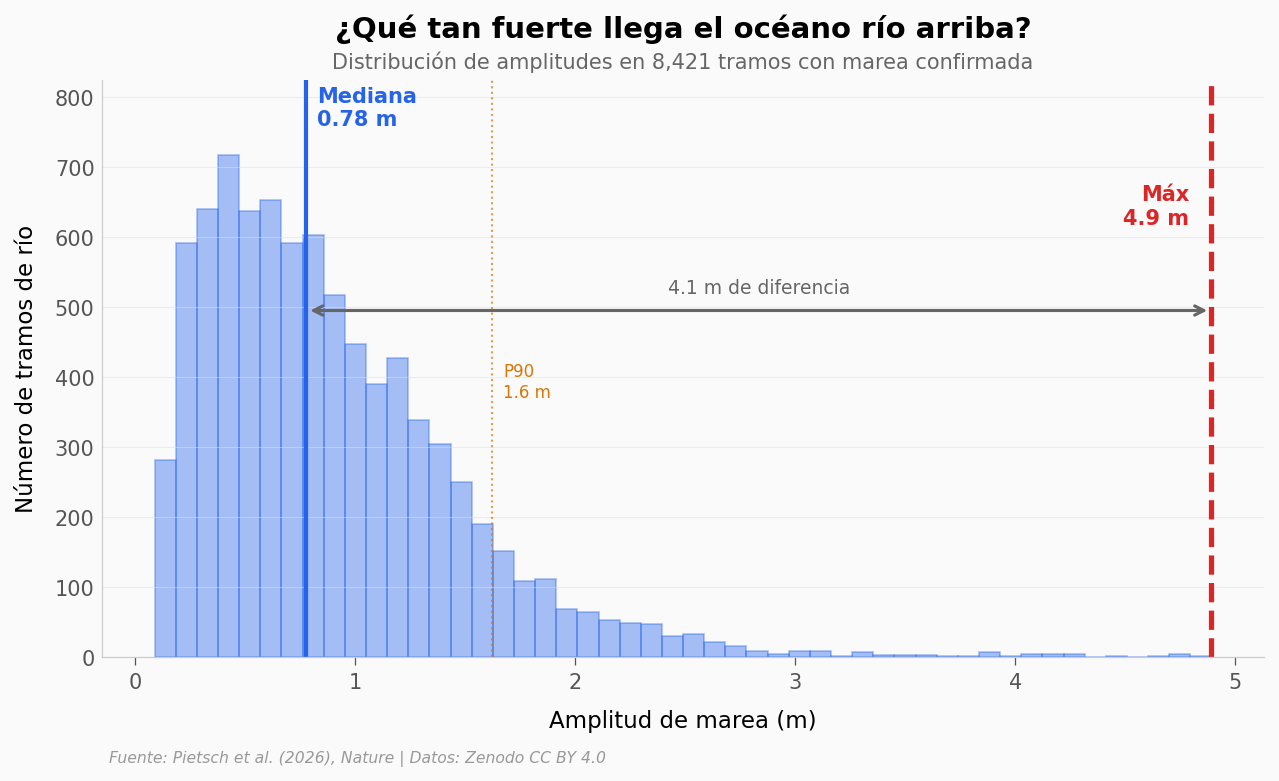

In [5]:
# ── Gráfica 4: Distribución de amplitudes ──
fig, ax = plt.subplots(figsize=(10, 5))

amps = rios[rios['amplitud_media_m'].notna()]['amplitud_media_m']
n_vals, bins, patches = ax.hist(amps, bins=50, color=COLOR_TIDAL, alpha=0.4,
                                 edgecolor=COLOR_TIDAL, linewidth=0.8)

y_max = n_vals.max() * 1.15
ax.set_ylim(0, y_max)

# Mediana
mediana = amps.median()
ax.axvline(x=mediana, color=COLOR_TIDAL, linewidth=2)
ax.text(mediana + 0.05, y_max * 0.92, f'Mediana\n{mediana:.2f} m',
        fontsize=10, fontweight='bold', color=COLOR_TIDAL)

# Máximo
maximo = amps.max()
ax.axvline(x=maximo, color=COLOR_ALERTA, linewidth=2.5, linestyle='--')
ax.text(maximo - 0.1, y_max * 0.75, f'Máx\n{maximo:.1f} m',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right')

# Flecha: mediana → max
ax.annotate('', xy=(maximo, y_max * 0.6), xytext=(mediana, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + maximo) / 2, y_max * 0.63,
        f'{maximo - mediana:.1f} m de diferencia',
        ha='center', fontsize=9, color='#666666')

# P90 y P95
p90 = amps.quantile(0.90)
p95 = amps.quantile(0.95)
ax.axvline(x=p90, color='#D97706', linewidth=1, linestyle=':', alpha=0.7)
ax.text(p90 + 0.05, y_max * 0.45, f'P90\n{p90:.1f} m', fontsize=8, color='#D97706')

ax.set_xlabel('Amplitud de marea (m)', fontsize=11)
ax.set_ylabel('Número de tramos de río', fontsize=11)
ax.set_title('¿Qué tan fuerte llega el océano río arriba?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución de amplitudes en {len(amps):,} tramos con marea confirmada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_amplitudes.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| "3,172 coastal rivers" con marea | ⚠️ Parcial | Nuestros datos tienen 20,910 tramos tidal (segments SWORD). Agruparlos en ríos requiere metadata SWORD adicional. El orden de magnitud es consistente (~3,000-5,000 sistemas fluviales) |
| "165,000+ river km influenced by tides" | ⚠️ No verificable | No tenemos longitud por tramo. Estimación: ~20K tramos × ~8 km ≈ 160K km (consistente) |
| "700M+ people live near" | ❌ No verificable | Requiere datos de población geoespaciales no incluidos |
| "16% affected by dams" | ❌ No verificable | Requiere datos de represas no incluidos |
| Oceanía y Asia Sur/Este más tidal | ✅ | 61% y 64% respectivamente, vs 36% Ártico |
| Amplitud media ~1 m | ✅ | 0.90 m (mediana 0.78 m), n=8,421 |
| Dominancia semidiurna global | ✅ | 49% semidiurna, 44% mixta, 7% diurna (n=8,421) |

> **Limitaciones:** (1) Los datos públicos son tramos SWORD, no ríos completos — la agrupación del paper requiere metadata adicional. (2) No tenemos longitud por tramo ni datos de población. (3) Solo se incluyen tramos con amplitud confirmada ("tide"), no los "likely tide". (4) Los continentes SWORD no coinciden exactamente con la definición geográfica estándar (ej: Rusia se divide entre Asia Norte y Europa).

## Ahora tú

1. **¿Cuál es el río más extremo?** Los tramos con amplitud >3 m son raros. ¿En qué continente están? Filtra `rios[rios['amplitud_max_m'] > 3]` y explora.

2. **¿Es la marea diurna más débil?** Compara la amplitud media de ríos semidiurnos vs diurnos vs mixtos. ¿El tipo de marea afecta la intensidad?

3. **¿Hay un "cinturón de mareas"?** Algunos continentes tienen mareas mucho más fuertes que otros. ¿Se puede inferir un patrón geográfico (latitud, tipo de costa)?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Los ríos con marea diurna tienen amplitudes diferentes?

amp_por_tipo = tipos.groupby('tipo_marea').agg(
    n=('amplitud_m2_media_m', 'count'),
    amp_m2_media=('amplitud_m2_media_m', 'mean'),
    amp_o1_media=('amplitud_o1_media_m', 'mean'),
    ratio_medio=('ratio_o1_m2', 'median')
).round(3)

print("Amplitudes por tipo de marea:")
print(amp_por_tipo.to_string())

# ¿Hay diferencia significativa en M2 entre tipos?
semi = tipos[tipos['tipo_marea'] == 'semidiurna']['amplitud_m2_media_m']
mixta = tipos[tipos['tipo_marea'] == 'mixta']['amplitud_m2_media_m']
diurna = tipos[tipos['tipo_marea'] == 'diurna']['amplitud_m2_media_m']

stat, p = stats.kruskal(semi, mixta, diurna)
epsilon_sq = (stat - 2) / (len(tipos) - 1)
print(f"\nKruskal-Wallis (M2 entre tipos): H={stat:.1f}, p={p:.2e}, ε²={epsilon_sq:.3f}")
print(f"  Efecto {'grande' if epsilon_sq > 0.14 else 'medio' if epsilon_sq > 0.06 else 'pequeño'}")

# Tamaño de efecto por pares (Cohen's d)
for a_name, a_vals, b_name, b_vals in [('semi', semi, 'mixta', mixta), ('semi', semi, 'diurna', diurna), ('mixta', mixta, 'diurna', diurna)]:
    n1, n2 = len(a_vals), len(b_vals)
    pooled = np.sqrt(((n1-1)*a_vals.std()**2 + (n2-1)*b_vals.std()**2) / (n1+n2-2))
    d = (a_vals.mean() - b_vals.mean()) / pooled
    print(f"  Cohen's d ({a_name} vs {b_name}): {d:.2f}")

Amplitudes por tipo de marea:
               n  amp_m2_media  amp_o1_media  ratio_medio
tipo_marea                                               
diurna       601         0.205         0.475        2.134
mixta       3689         0.445         0.227        0.492
semidiurna  4131         0.999         0.125        0.131

Kruskal-Wallis (M2 entre tipos): H=3414.6, p=0.00e+00, ε²=0.405
  Efecto grande
  Cohen's d (semi vs mixta): 1.19
  Cohen's d (semi vs diurna): 1.52
  Cohen's d (mixta vs diurna): 0.75


---

### Créditos

- **Paper:** Pietsch, C. et al. (2026). Tidal dynamics across thousands of coastal rivers from SWOT. *Nature*. DOI: [10.1038/s41586-026-10287-z](https://doi.org/10.1038/s41586-026-10287-z)
- **Datos:** [Zenodo — SWOT River Tides](https://doi.org/10.5281/zenodo.15223861) (CC BY 4.0)
- **Red de ríos:** SWORD v17 ([Zenodo](https://doi.org/10.5281/zenodo.14727521))
- **Satélite:** SWOT (NASA/CNES, lanzado diciembre 2022)
- **Repo:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)